In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import parse_slurm as ps
import data_analysis as da
import glob
import pandas as pd

In [3]:
metric = 'Elapsed'

# Docking Protein-Protein Execution Time Analysis 

In [4]:
dpp = pd.read_csv('../data/data_dpp.csv')
dpp = ps.remove_outliers(dpp, threshold=2, column=metric)
dpp.loc[:, 'Elapsed'] = dpp['Elapsed'] / 3600 
dpp_time = dpp[['Elapsed', 'NCPUS']]

## Descriptive Analysis

In [5]:
for x in [4, 8, 16, 32]:
    group = dpp_time[dpp_time['NCPUS'] == x]
    print(group.describe())
    cv = group.std() / group.mean()
    print('cv', '   ', round(cv[metric], 6))

         Elapsed  NCPUS
count  20.000000   20.0
mean    1.298667    4.0
std     0.103706    0.0
min     1.202222    4.0
25%     1.213819    4.0
50%     1.266250    4.0
75%     1.314931    4.0
max     1.540556    4.0
cv     0.079856
         Elapsed  NCPUS
count  23.000000   23.0
mean    0.709505    8.0
std     0.016769    0.0
min     0.682222    8.0
25%     0.695972    8.0
50%     0.710833    8.0
75%     0.719306    8.0
max     0.751667    8.0
cv     0.023635
         Elapsed  NCPUS
count  14.000000   14.0
mean    0.462480   16.0
std     0.031752    0.0
min     0.440556   16.0
25%     0.445000   16.0
50%     0.448611   16.0
75%     0.460139   16.0
max     0.539722   16.0
cv     0.068657
         Elapsed  NCPUS
count  18.000000   18.0
mean    0.372793   32.0
std     0.023678    0.0
min     0.349444   32.0
25%     0.354236   32.0
50%     0.368611   32.0
75%     0.379792   32.0
max     0.433333   32.0
cv     0.063514


## Boxplots

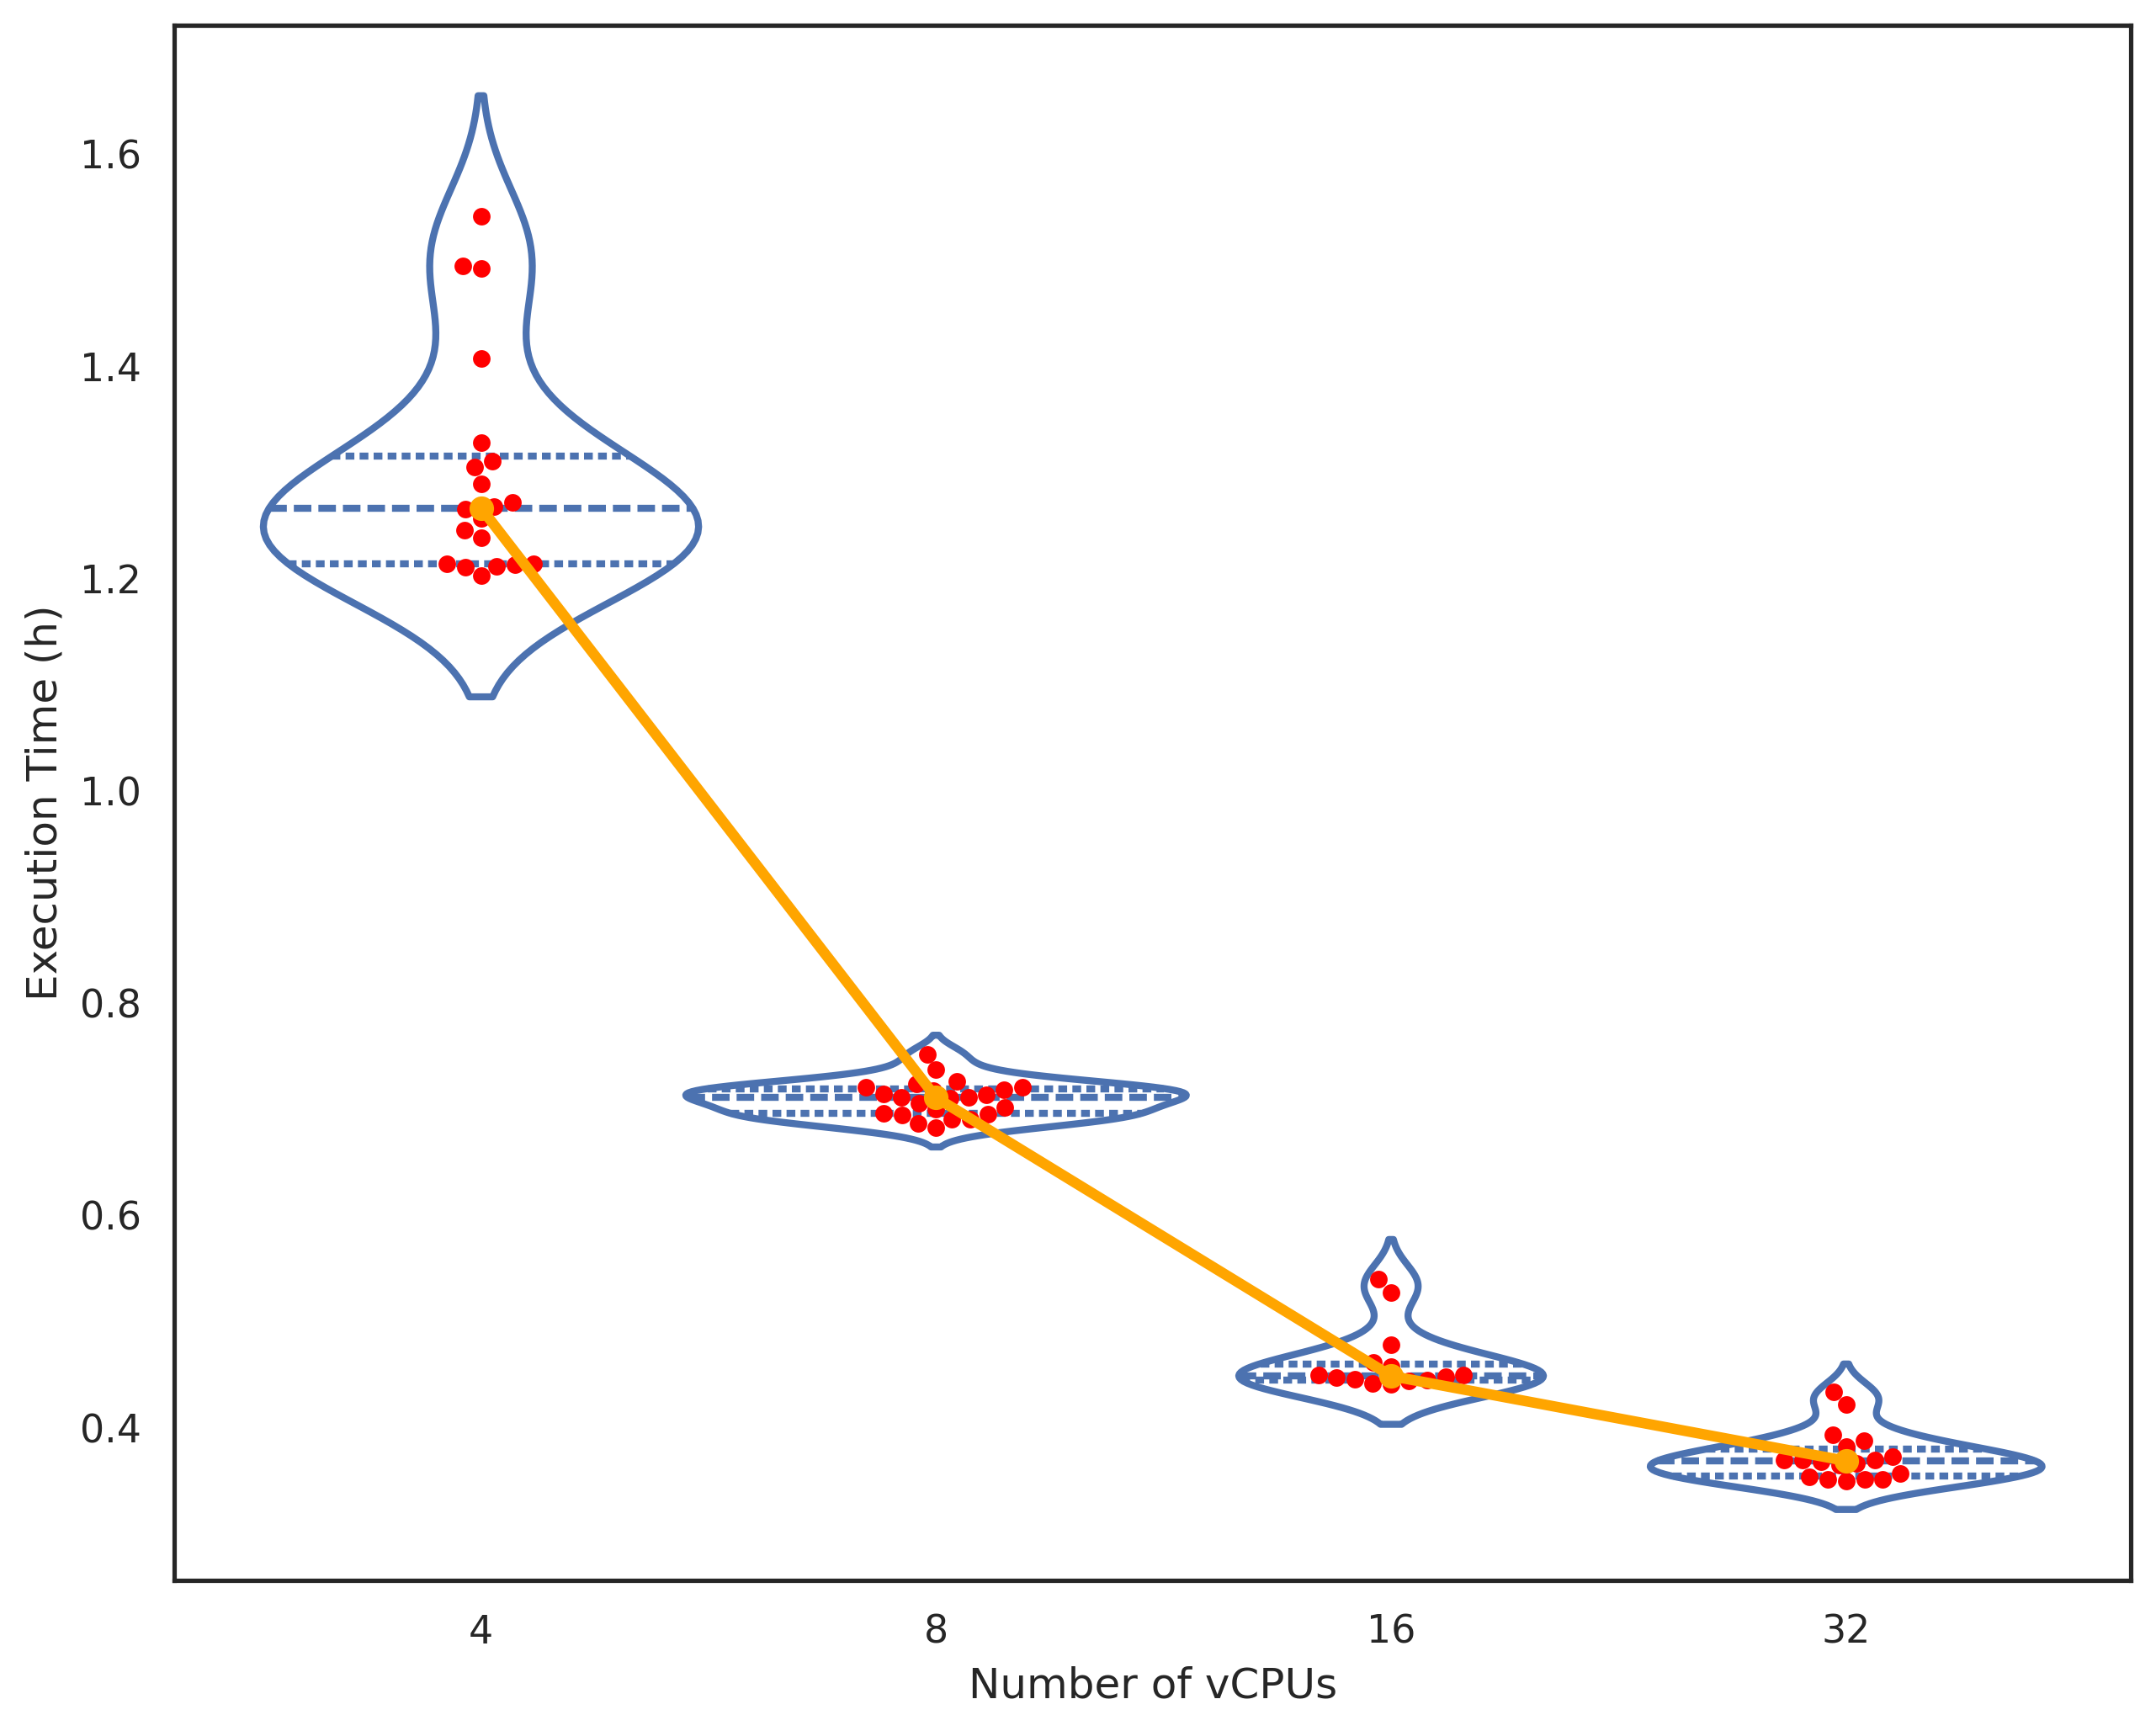

In [6]:
da.show_boxplot(
    dpp_time, "Execution Time of DPP Workflow at Varying Parallelism Degrees", metric=metric,
    x_label="Number of vCPUs", y_label="Execution Time (h)", store=True
)

### Normality Test: Shapiro-Wilk and QQ-Plots

In [7]:
normality = ps.test_normality(dpp_time, column=metric)
print(normality)

   NCPUS      STAT    PVALUE
0      4  0.807566  0.001123
1      8  0.967741  0.635101
2     16  0.667927  0.000175
3     32  0.834709  0.004906


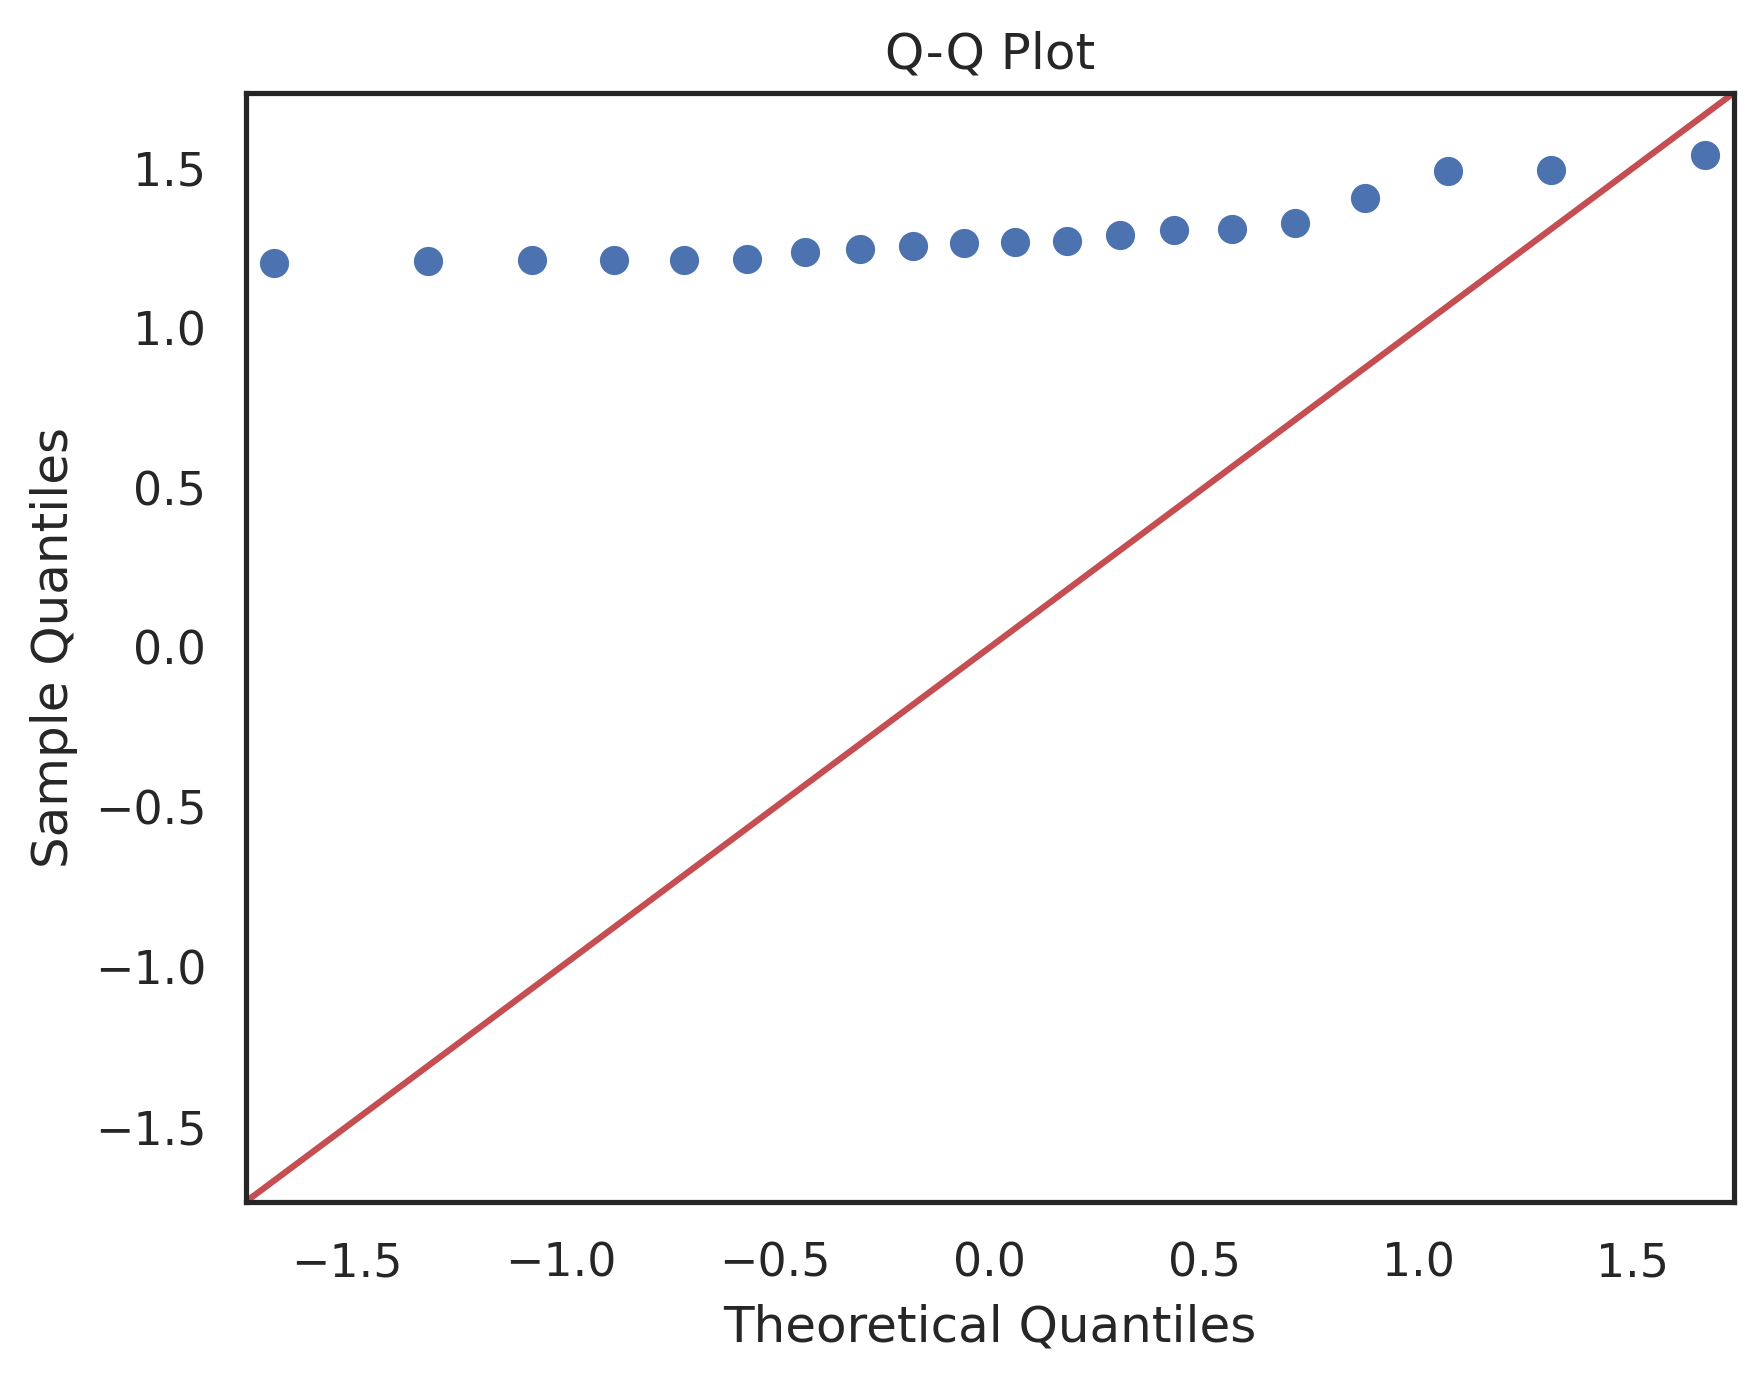

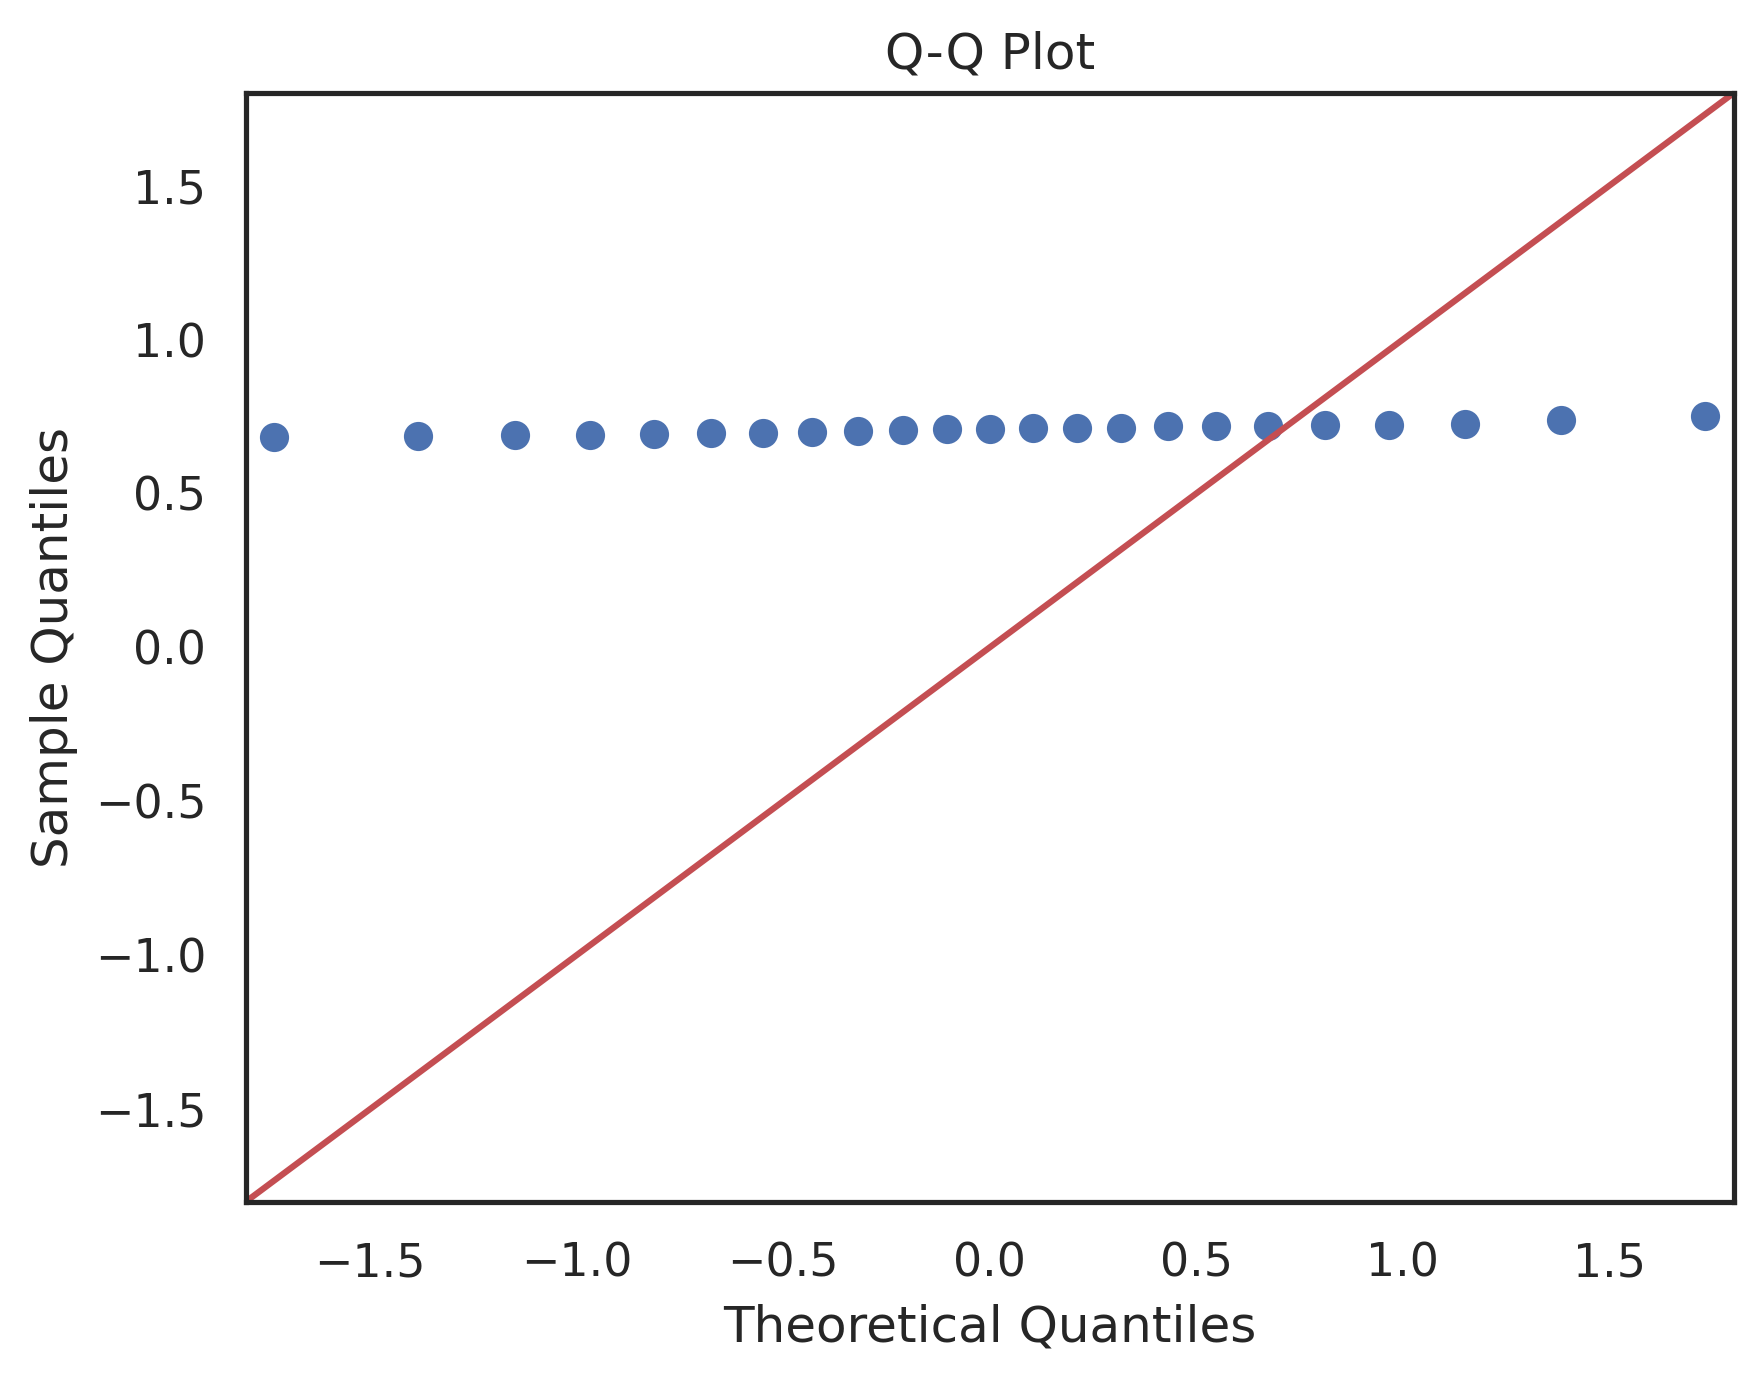

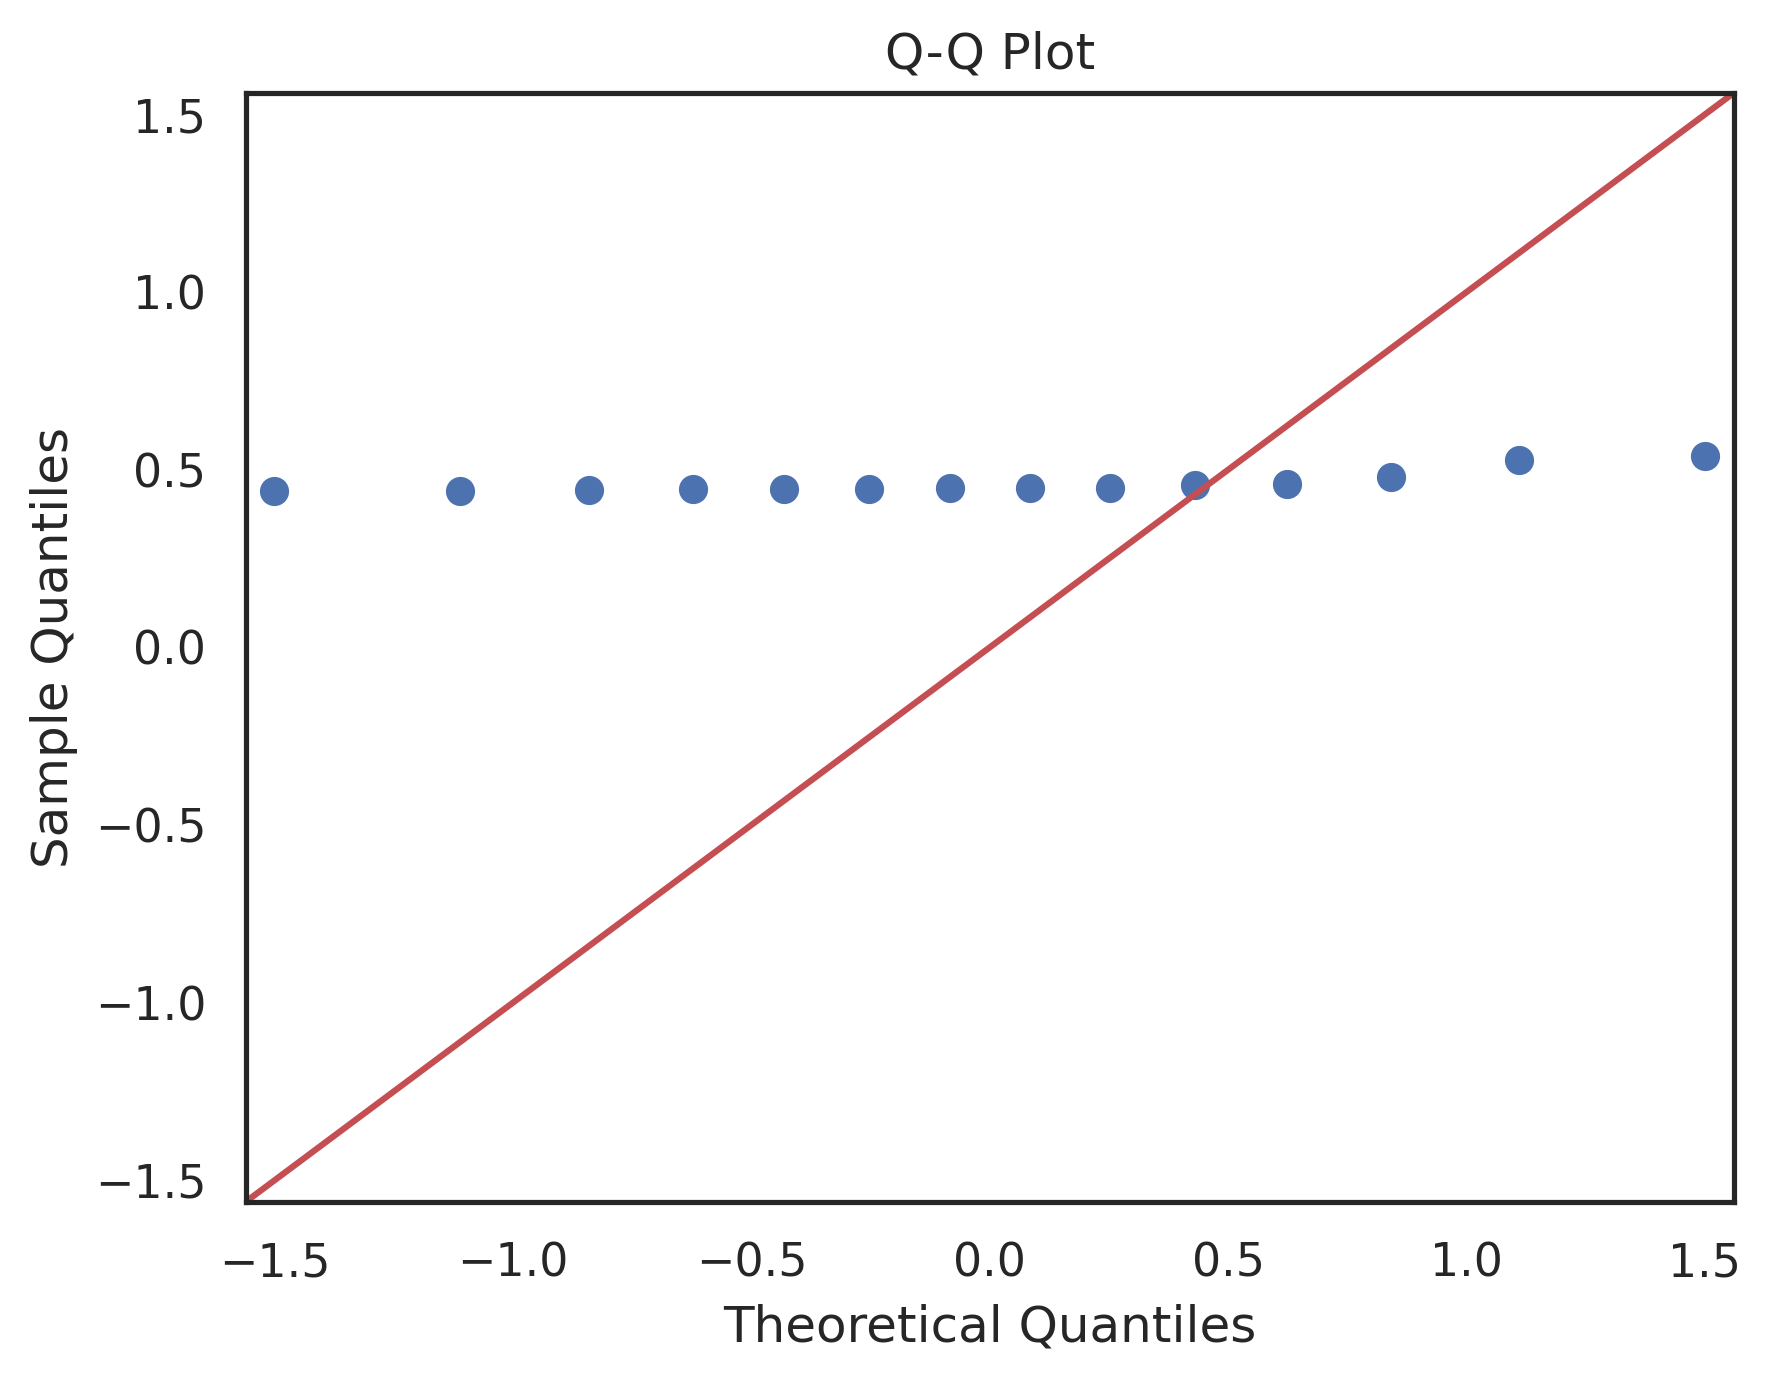

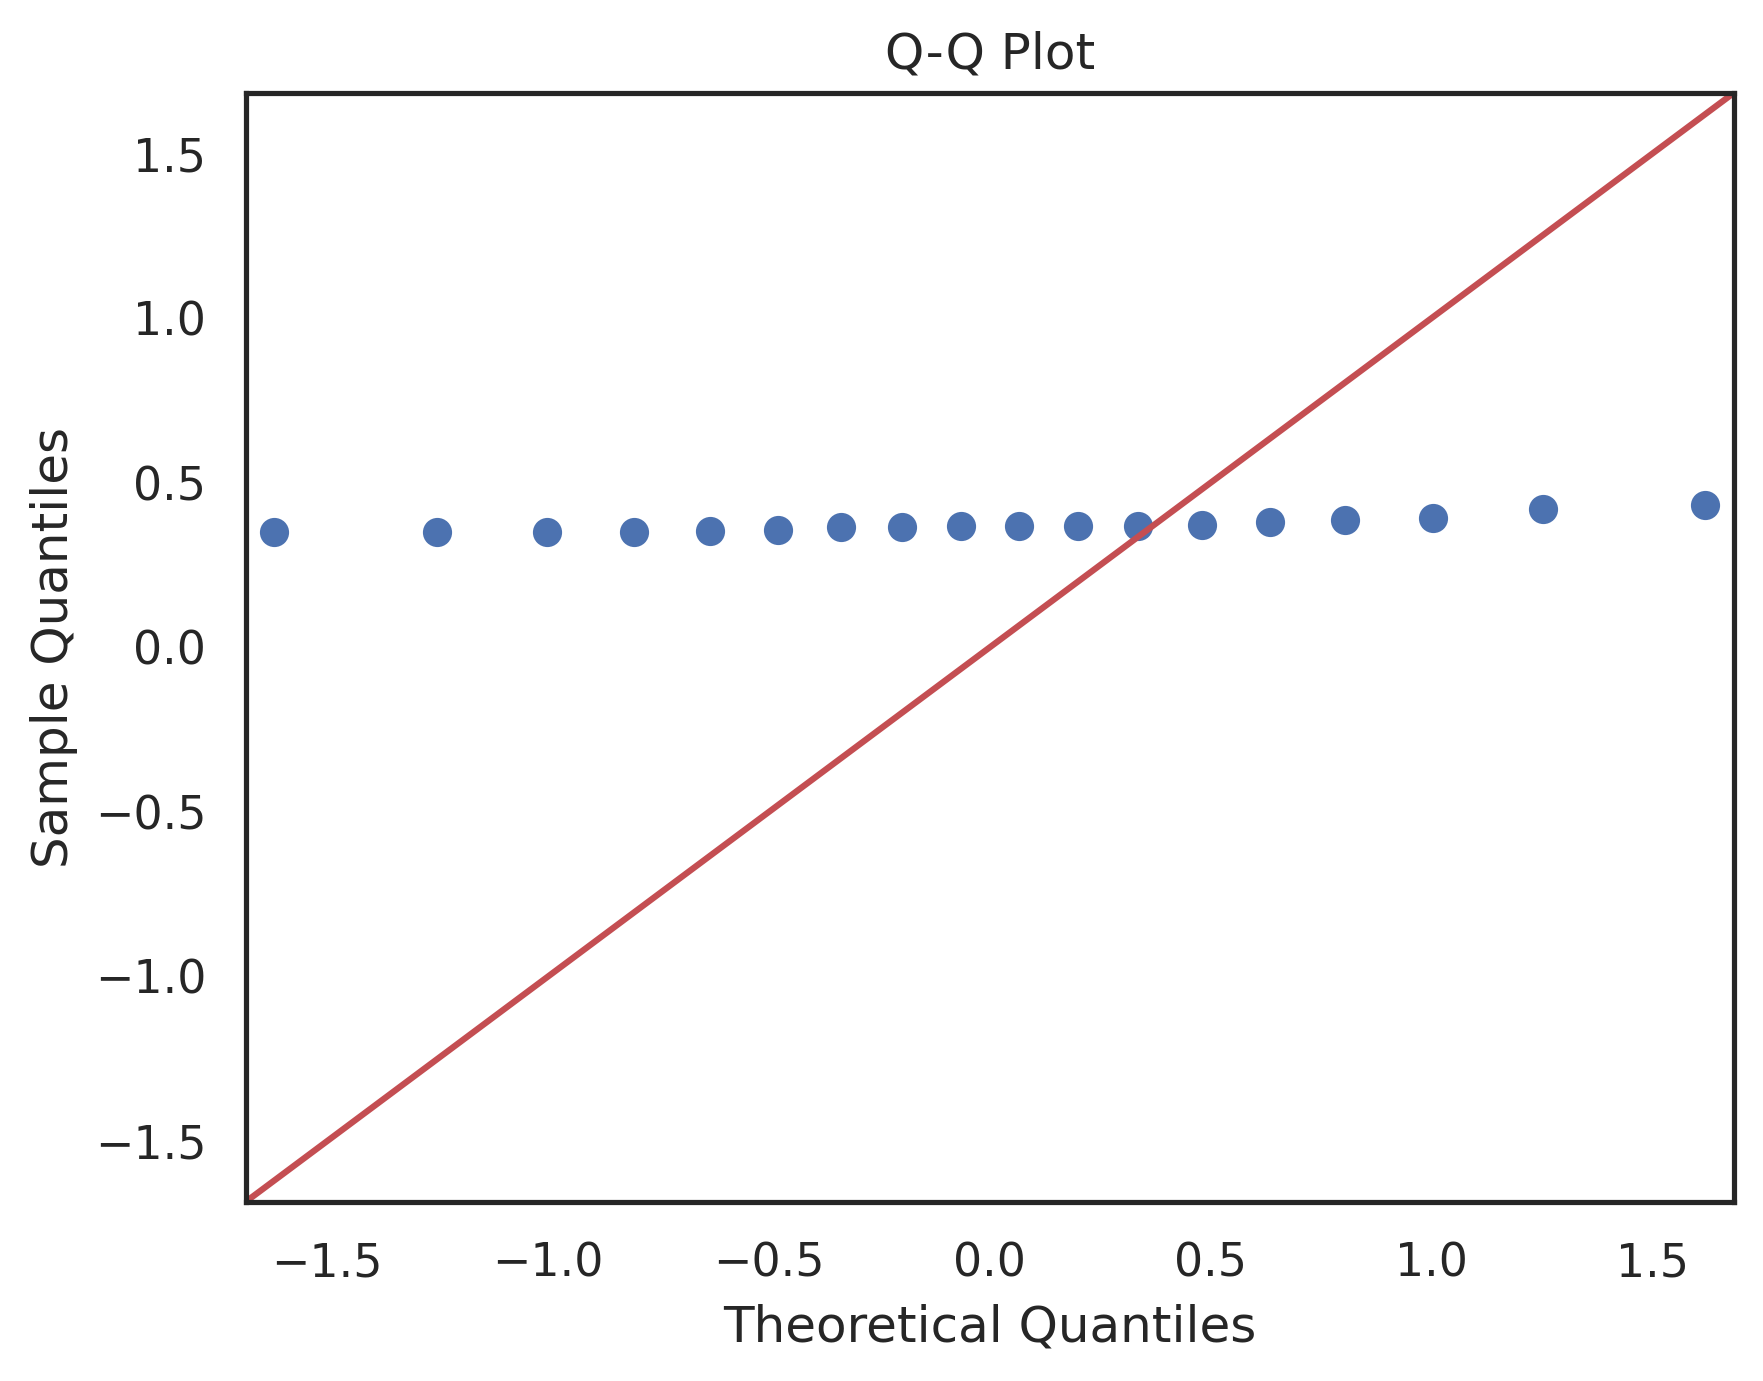

In [8]:
ps.generate_qq(dpp_time, column=metric)

## Hypothesis Testing: Kruskal-Wallis

In [9]:
ps.test_hypothesis_kruskal(dpp_time, column=metric)

(68.97248854874961, 7.0836566655165684e-15)

## Effect Size: Cliff's Delta

In [10]:
ps.calc_cliffs_delta(dpp_time, column=metric)

,CPUS-GROUPS,Value,Result
0,"(4, 8)",1.0,large
1,"(8, 16)",1.0,large
2,"(16, 32)",1.0,large


## Effect Size: Percentage Improvement

In [11]:
ps.calc_groups_improvement(dpp_time, column=metric)

,CPU-GROUPS,Median Improvement,Median Delta,Mean Improvement,Mean Delta
0,"(4, 8)",78.135991,0.555417,83.038453,0.589162
1,"(8, 16)",58.452012,0.262222,53.413031,0.247025
2,"(16, 32)",21.703090,0.080000,24.058096,0.089687
3,"(4, 32)",243.519216,0.897639,248.361138,0.925873


# Docking Antibody-Antigen Execution Time Analysis 

In [12]:
daa = pd.read_csv('../data/data_daa.csv')
daa = ps.remove_outliers(daa, threshold=1, column=metric)
daa.loc[:, 'Elapsed'] = daa['Elapsed'] / 3600 
daa_time = daa[['Elapsed', 'NCPUS']]

# Descriptive Analysis

In [13]:
for x in [4, 8, 16, 32]:
    group = daa_time[daa_time['NCPUS'] == x]
    print(group.describe())
    cv = group.std() / group.mean()
    print('cv', '   ', round(cv[metric], 6))  

         Elapsed  NCPUS
count  15.000000   15.0
mean   17.662815    4.0
std     0.341437    0.0
min    17.262222    4.0
25%    17.411528    4.0
50%    17.488889    4.0
75%    18.000278    4.0
max    18.247222    4.0
cv     0.019331
         Elapsed  NCPUS
count  16.000000   16.0
mean   10.034479    8.0
std     0.178655    0.0
min     9.835000    8.0
25%     9.886667    8.0
50%     9.978472    8.0
75%    10.184167    8.0
max    10.381944    8.0
cv     0.017804
        Elapsed  NCPUS
count  8.000000    8.0
mean   6.070937   16.0
std    0.082528    0.0
min    5.980278   16.0
25%    5.991181   16.0
50%    6.076806   16.0
75%    6.149583   16.0
max    6.155556   16.0
cv     0.013594
        Elapsed  NCPUS
count  8.000000    8.0
mean   4.793264   32.0
std    0.060485    0.0
min    4.722222   32.0
25%    4.755556   32.0
50%    4.775417   32.0
75%    4.835486   32.0
max    4.900556   32.0
cv     0.012619


## Boxplots

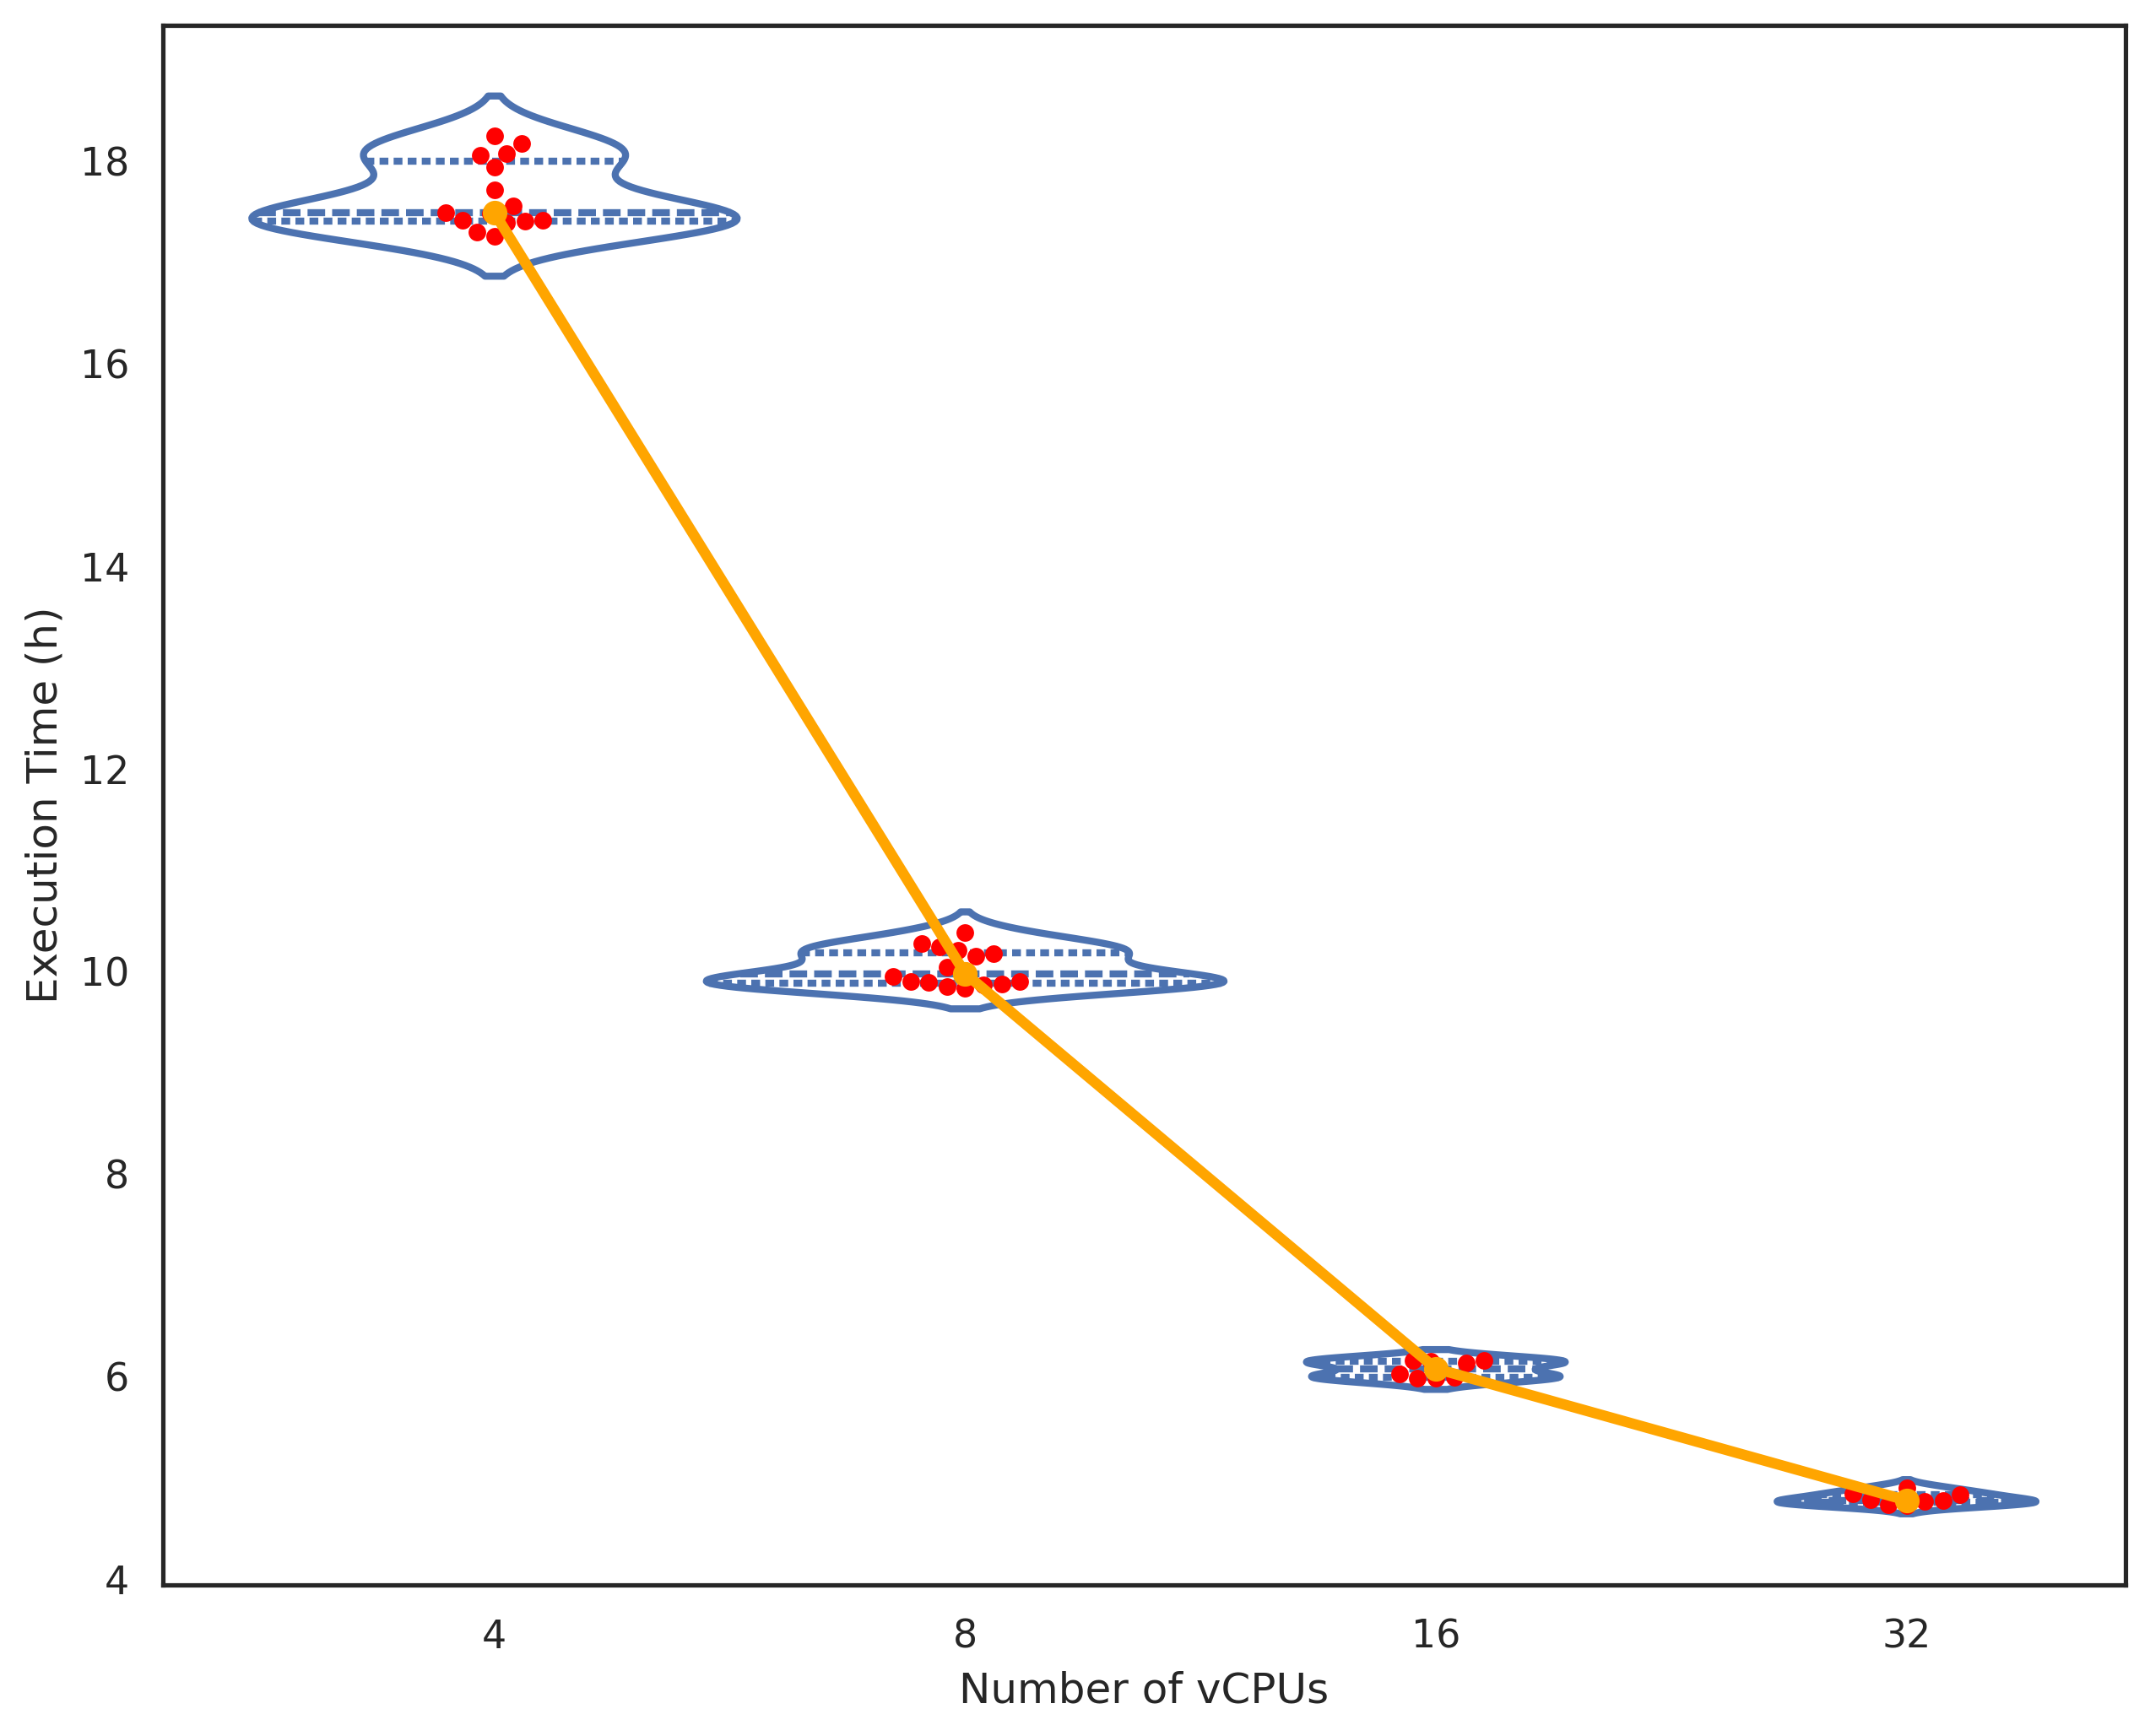

In [14]:
da.show_boxplot(
    daa_time, "Execution Time of DAA Workflow at Varying Parallelism Degrees", metric=metric,
    x_label="Number of vCPUs", y_label="Execution Time (h)", store=True
)

## Normality Test: Shapiro-Wilk and QQ-Plots

In [15]:
normality = ps.test_normality(daa_time, column=metric)
print(normality)

   NCPUS      STAT    PVALUE
0      4  0.864733  0.028260
1      8  0.889092  0.053893
2     16  0.785491  0.019979
3     32  0.936494  0.576951


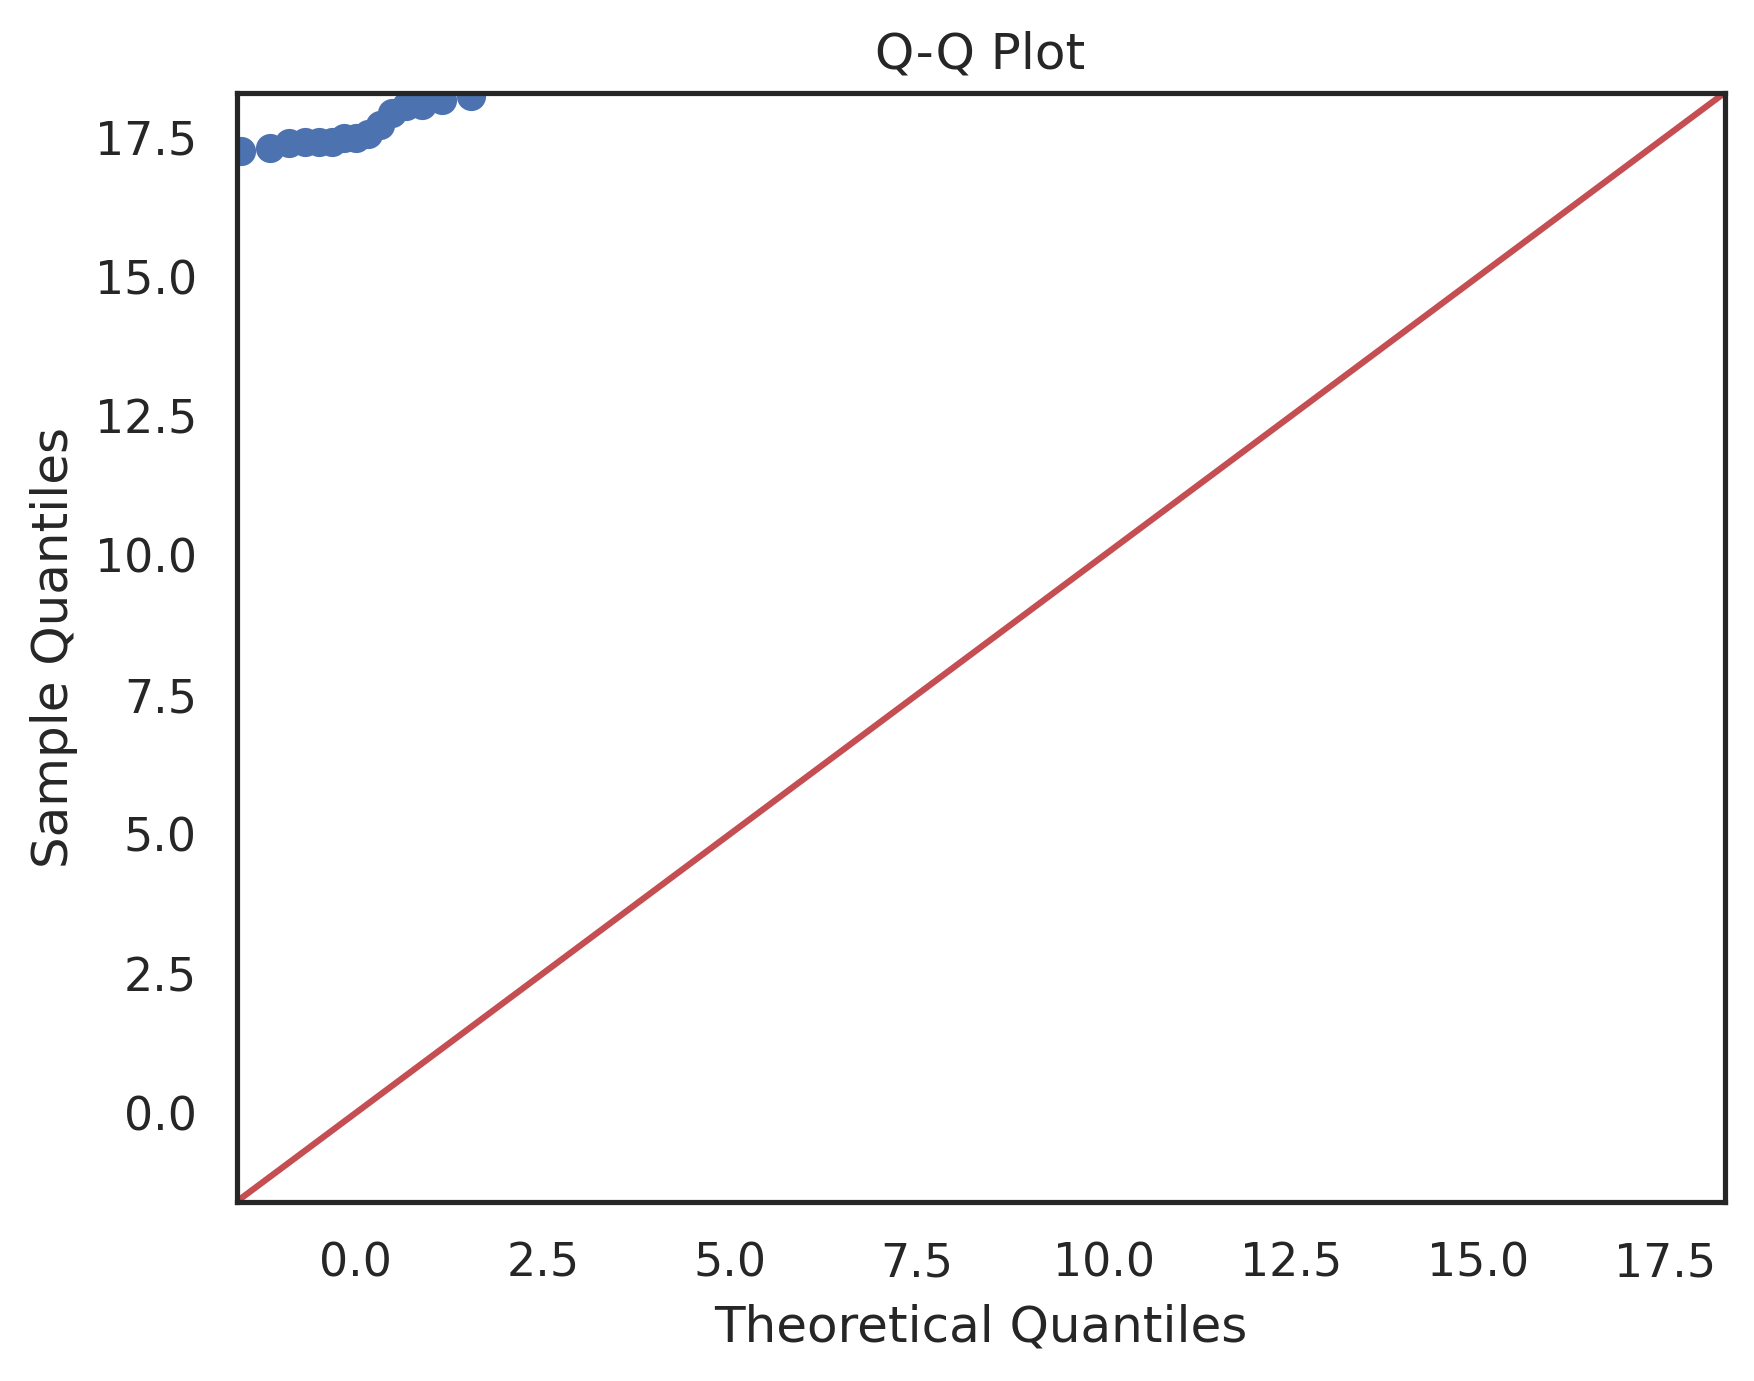

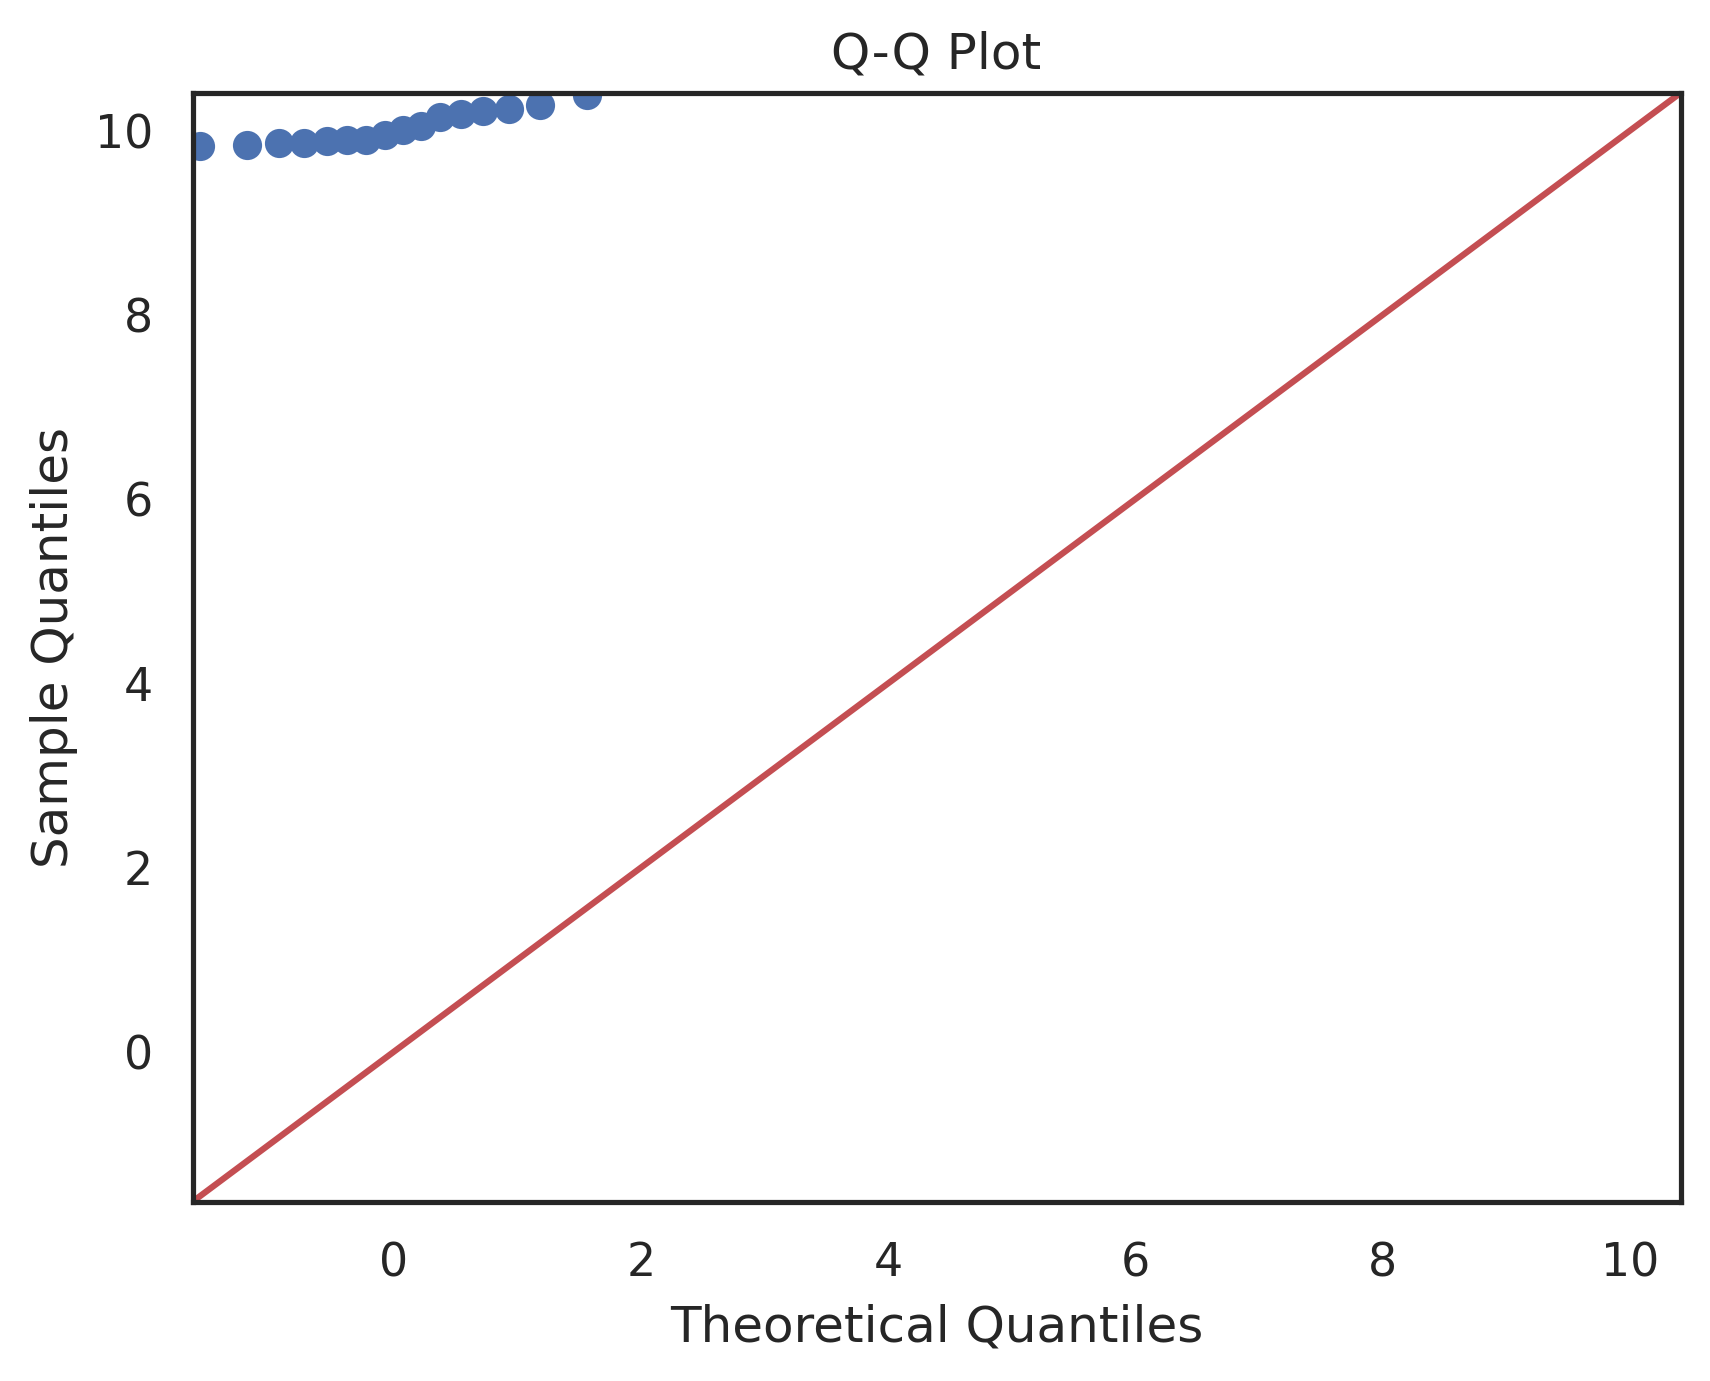

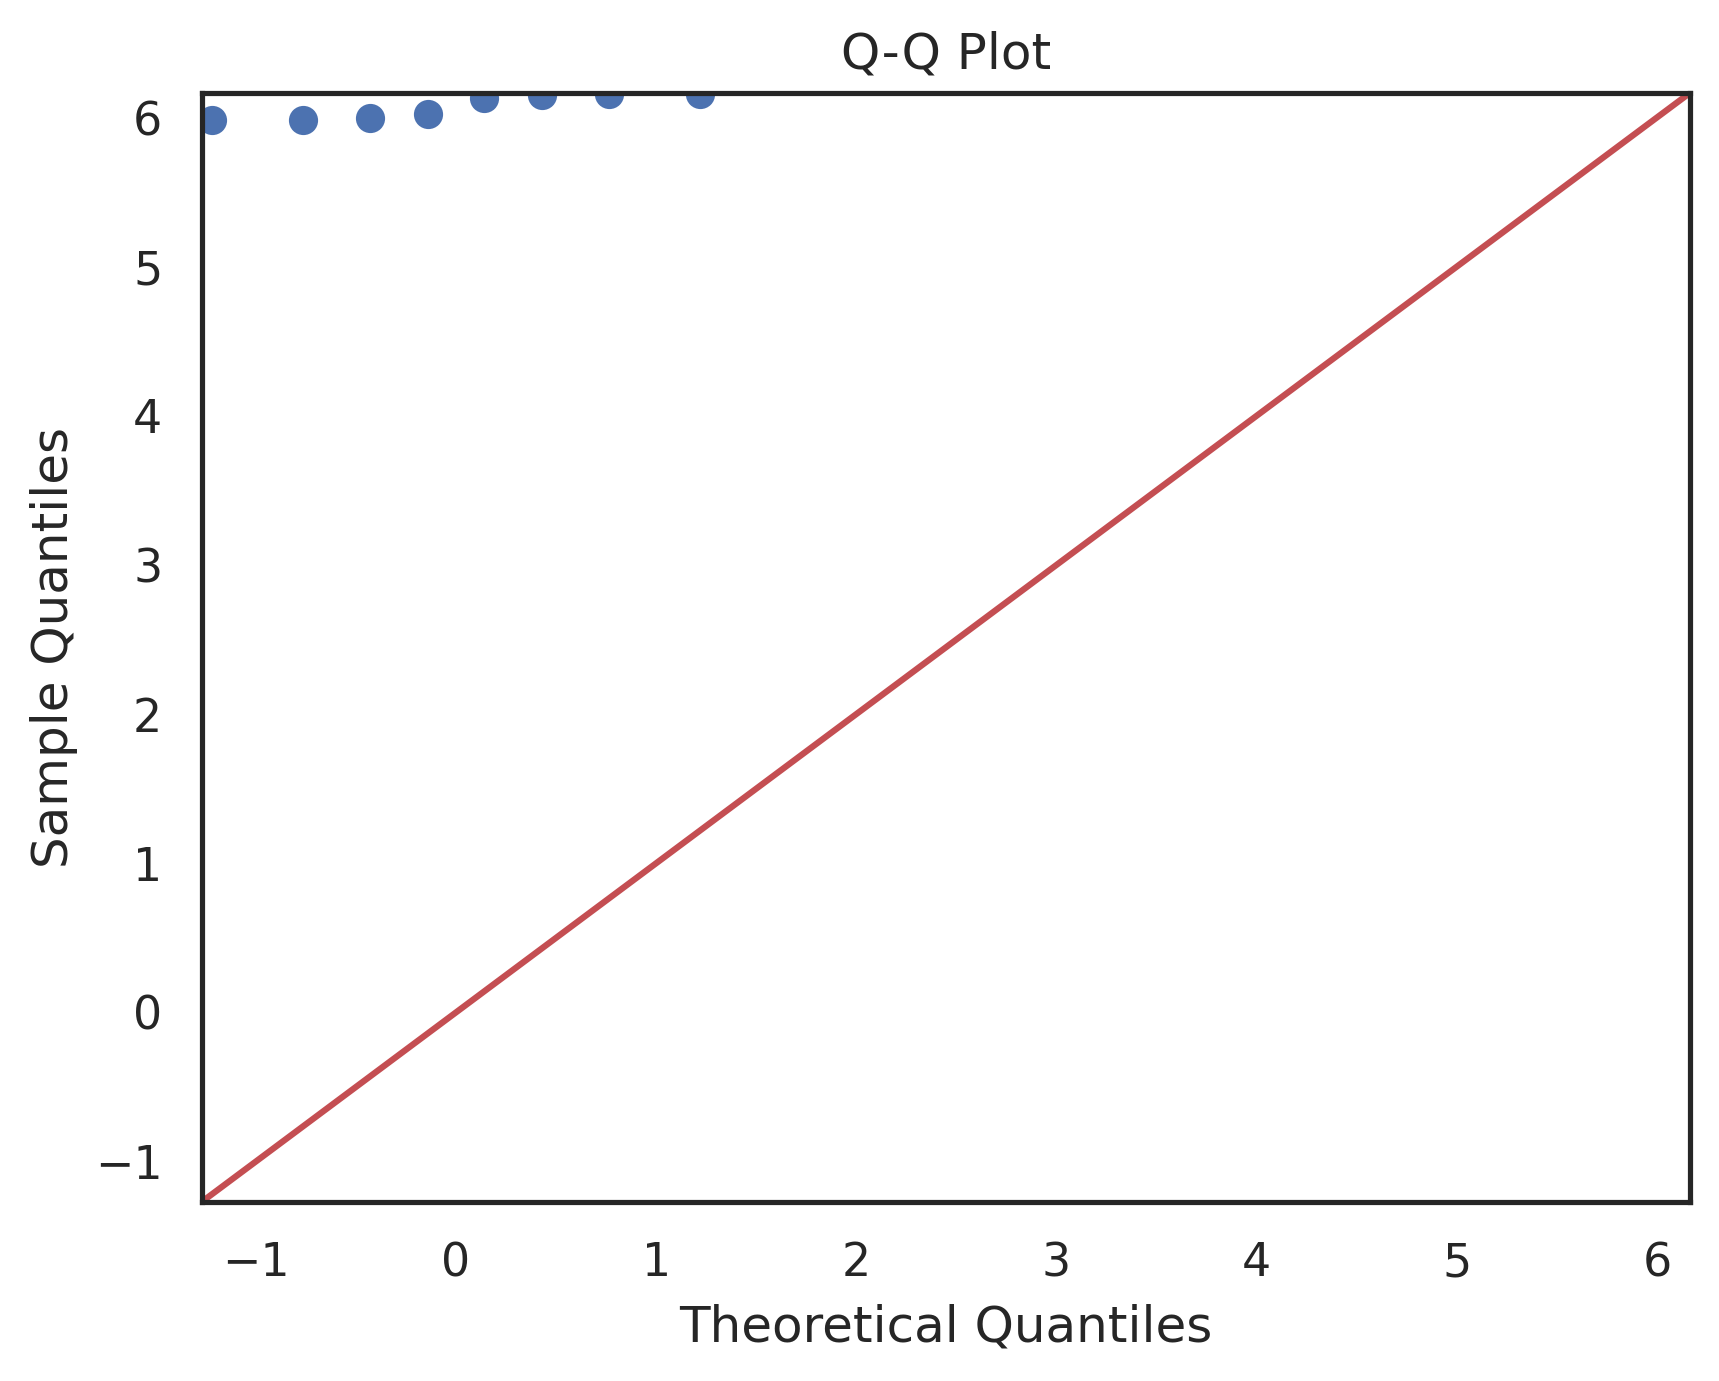

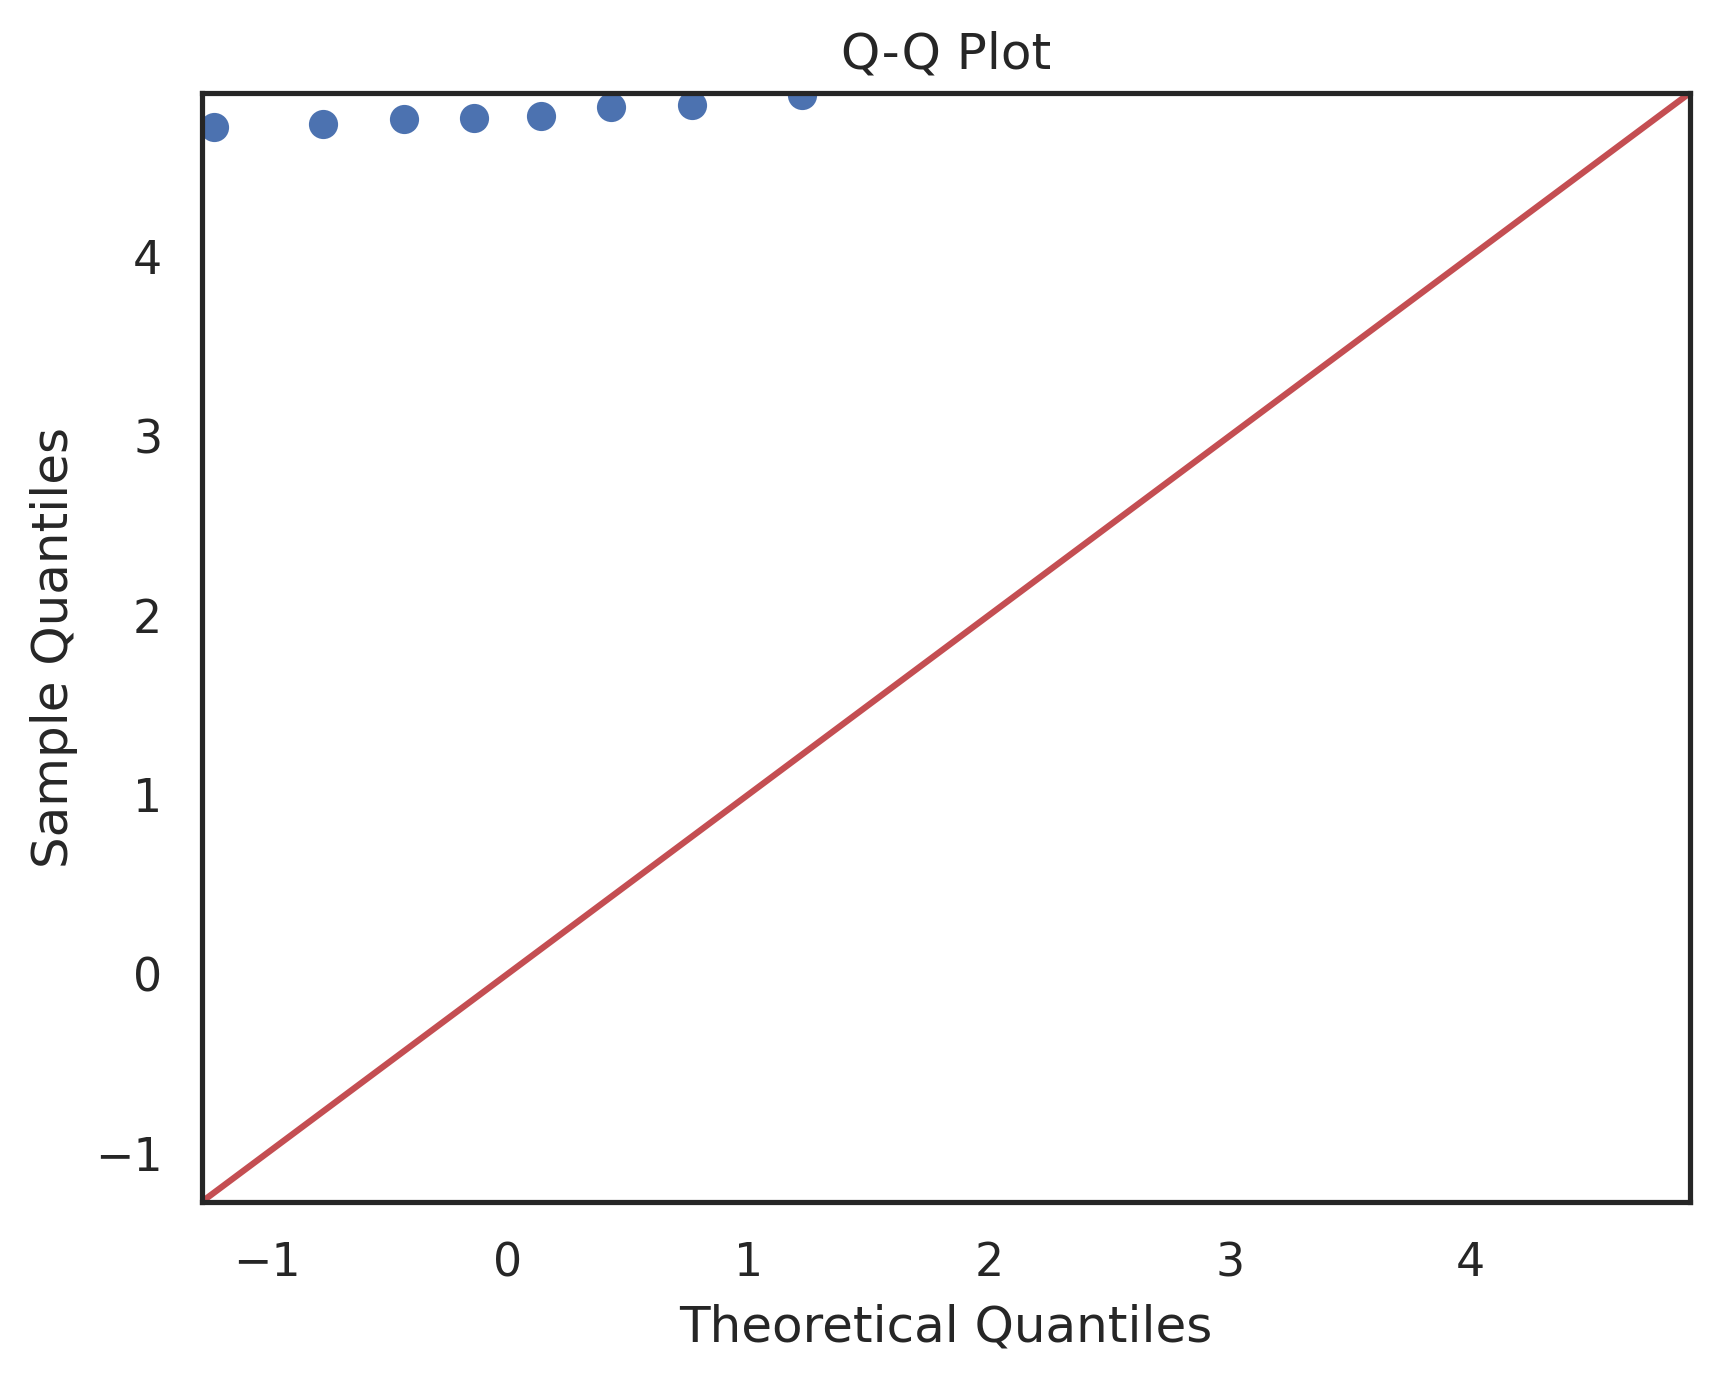

In [16]:
ps.generate_qq(daa_time, column=metric)

## Hypothesis Testing: Kruskal-Wallis

In [17]:
ps.test_hypothesis_kruskal(daa_time, column=metric)

(42.25531914893617, 3.541525733752014e-09)

## Effect Size: Cliff's Delta

In [18]:
ps.calc_cliffs_delta(daa_time, column=metric)

,CPUS-GROUPS,Value,Result
0,"(4, 8)",1.0,large
1,"(8, 16)",1.0,large
2,"(16, 32)",1.0,large


## Effect Size: Percentage Improvement

In [19]:
ps.calc_groups_improvement(daa_time, column=metric)

,CPU-GROUPS,Median Improvement,Median Delta,Mean Improvement,Mean Delta
0,"(4, 8)",75.266198,7.510417,76.021242,7.628336
1,"(8, 16)",64.205883,3.901667,65.287143,3.963542
2,"(16, 32)",27.251840,1.301389,26.655608,1.277674
3,"(4, 32)",266.227496,12.713472,268.492435,12.869551
